<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/blob/main/Analyse_LLO_feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Решаем задачу регрессии для time

In [51]:
import pandas as pd
import numpy as np

import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

In [53]:
data_link = "https://github.com/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/raw/refs/heads/main/med_dataset_cardio.xlsx"
data = pd.read_excel(data_link, header=0)
data.rename(columns={"0_na, 1_mi": "severity", "0_no, 1_ther, 2_card": "doctor"}, inplace=True);
data.drop(columns=["card"], inplace=True)
data.drop(columns=["na"], inplace=True)
data.drop(columns=["dmonit"], inplace=True)
data["target"] = data["result_cvd"]
data.drop(columns=["result", "result_cvd"], inplace=True)

In [54]:
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df = data.copy()

# Separate majority and minority classes
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]

print(f"\nClass 0 samples: {len(df_majority)}")
print(f"Class 1 samples: {len(df_minority)}")

# Method 1: Downsample majority class to match minority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,  # sample without replacement
                                   n_samples=len(df_minority),  # match minority class size
                                   random_state=37)  # reproducible results

# Combine downsampled majority with minority
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

print(f"\nAfter downsampling - balanced dataset:")
print(df_downsampled['target'].value_counts())
print(f"Total samples after downsampling: {len(df_downsampled)}")

# Method 2: Upsample minority class using SMOTE to match majority class
# Prepare data for SMOTE: features and target
X_smote = df.drop('target', axis=1)
y_smote = df['target']

smote = SMOTE(random_state=37)
X_resampled, y_resampled = smote.fit_resample(X_smote, y_smote)

# Combine resampled features and target into a new DataFrame
df_upsampled = pd.concat([X_resampled, y_resampled], axis=1)

print(f"\nAfter upsampling with SMOTE - balanced dataset:")
print(df_upsampled['target'].value_counts())
print(f"Total samples after upsampling: {len(df_upsampled)}")


Class 0 samples: 1354
Class 1 samples: 152

After downsampling - balanced dataset:
target
0    152
1    152
Name: count, dtype: int64
Total samples after downsampling: 304

After upsampling with SMOTE - balanced dataset:
target
0    1354
1    1354
Name: count, dtype: int64
Total samples after upsampling: 2708


In [103]:
y = df_upsampled['time']
# Explicitly create a list of columns to drop for the regression features
columns_to_drop_for_regressor = ['time', 'target']
if 'age_group' in df_upsampled.columns:
    columns_to_drop_for_regressor.append('age_group')
X = df_upsampled.drop(columns=columns_to_drop_for_regressor)

# Store the feature names that gb_reg was trained on
original_gb_reg_features = X.columns.tolist()

#делим выборку на тестовую и тренировочную
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

#данные имеют разную природу, поэтому нужно их стандартизовать
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2166, 30)  |  Test: (542, 30)


In [56]:
# линейная регрессия
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression")
print(f"  R²   = {lr_r2:.4f}")
print(f"  RMSE = {lr_rmse:.4f}")
print(f"  MAE  = {lr_mae:.4f}")
print(f"\nКоэффициенты модели:")
coef_df = pd.DataFrame({'feature': X.columns, 'coef': lr.coef_}).sort_values('coef')
print(coef_df.to_string(index=False))

Linear Regression
  R²   = 0.4826
  RMSE = 389.9284
  MAE  = 316.6099

Коэффициенты модели:
     feature       coef
    severity -82.192957
         glu -72.457361
        crea -61.649805
         bpm -52.362951
         ldl -46.822007
         age -46.059769
   pulm_cong -28.570592
         llo  -8.439040
     sum_cad  -0.346749
          hb   0.441079
      leukoc   0.529431
        onco   4.139093
        copd   7.756621
     tromboc   9.780790
      insult  12.959180
     ef_hosp  14.731043
          af  24.064542
      gender  34.445668
       sysAP  34.698107
    stenting  37.332949
    ca_delay  37.888564
         bmi  43.260171
         ckd  43.435428
      nstemi  44.681167
     smoking  45.822414
          dm  66.647591
total_revasc  82.414948
       stemi  82.612745
      t_chol 111.145819
      doctor 198.720653


In [57]:
# деревья решений
dt_reg = DecisionTreeRegressor(random_state=37, max_depth=10)
dt_reg.fit(X_train_sc, y_train)

y_pred_dt = dt_reg.predict(X_test_sc)

dt_r2   = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae  = mean_absolute_error(y_test, y_pred_dt)

# Train vs Test — проверяем переобучение
dt_r2_train = r2_score(y_train, dt_reg.predict(X_train_sc))

print("Decision Tree (max_depth=10)")
print(f"  Train R² = {dt_r2_train:.4f}")
print(f"  Test  R² = {dt_r2:.4f}")
print(f"  RMSE     = {dt_rmse:.4f}")
print(f"  MAE      = {dt_mae:.4f}")
if dt_r2_train - dt_r2 > 0.1:
    print("Внимание: разрыв Train/Test > 0.1 — возможно переобучение!")

Decision Tree (max_depth=10)
  Train R² = 0.8636
  Test  R² = 0.3424
  RMSE     = 439.6162
  MAE      = 293.4823
Внимание: разрыв Train/Test > 0.1 — возможно переобучение!


Random Forest (100 деревьев, max_depth=10)
  R²   = 0.6561
  RMSE = 317.9243
  MAE  = 242.7310


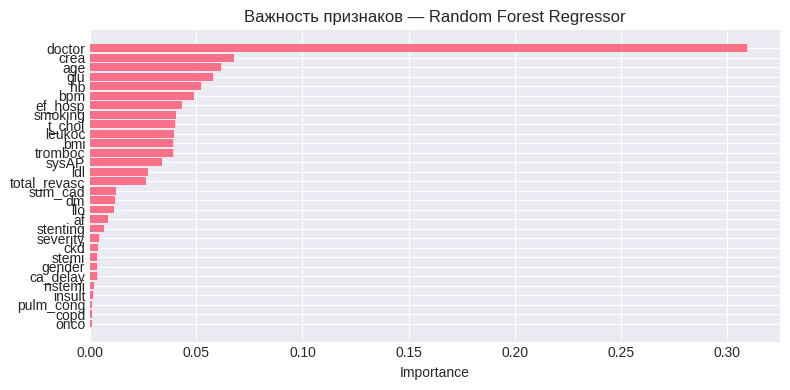

In [58]:
# случайный лес
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train_sc, y_train)

y_pred_rf = rf_reg.predict(X_test_sc)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest (100 деревьев, max_depth=10)")
print(f"  R²   = {rf_r2:.4f}")
print(f"  RMSE = {rf_rmse:.4f}")
print(f"  MAE  = {rf_mae:.4f}")

# Важность признаков
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.title('Важность признаков — Random Forest Regressor')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Gradient Boosting (100 деревьев, max_depth=5)
  R²   = 0.6086
  RMSE = 339.1516
  MAE  = 268.6412


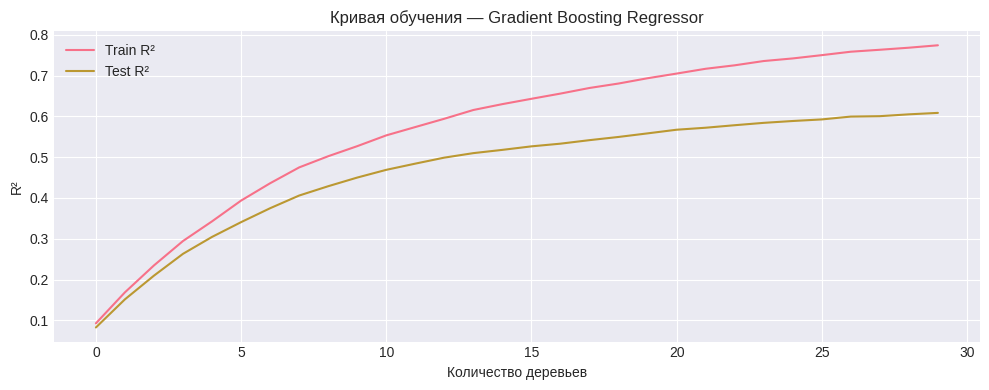

In [59]:
# градиентный бустинг
gb_reg = GradientBoostingRegressor(n_estimators=30, random_state=42, max_depth=5)
gb_reg.fit(X_train_sc, y_train)

y_pred_gb = gb_reg.predict(X_test_sc)

gb_r2   = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  R²   = {gb_r2:.4f}")
print(f"  RMSE = {gb_rmse:.4f}")
print(f"  MAE  = {gb_mae:.4f}")

# Кривая обучения (staged_predict)
train_scores = [r2_score(y_train, y_pred) for y_pred in gb_reg.staged_predict(X_train_sc)]
test_scores  = [r2_score(y_test,  y_pred) for y_pred in gb_reg.staged_predict(X_test_sc)]

plt.figure(figsize=(10, 4))
plt.plot(train_scores, label='Train R²', linewidth=1.5)
plt.plot(test_scores,  label='Test R²',  linewidth=1.5)
plt.xlabel('Количество деревьев')
plt.ylabel('R²')
plt.title('Кривая обучения — Gradient Boosting Regressor')
plt.legend()
plt.tight_layout()
plt.show()

Сводная таблица — Регрессия:
                       R²      RMSE       MAE
Model                                        
Linear Regression  0.4826  389.9284  316.6099
Decision Tree      0.3424  439.6162  293.4823
Random Forest      0.6561  317.9243  242.7310
Gradient Boosting  0.6086  339.1516  268.6412

Лучшая модель по R²: Random Forest (0.6561)


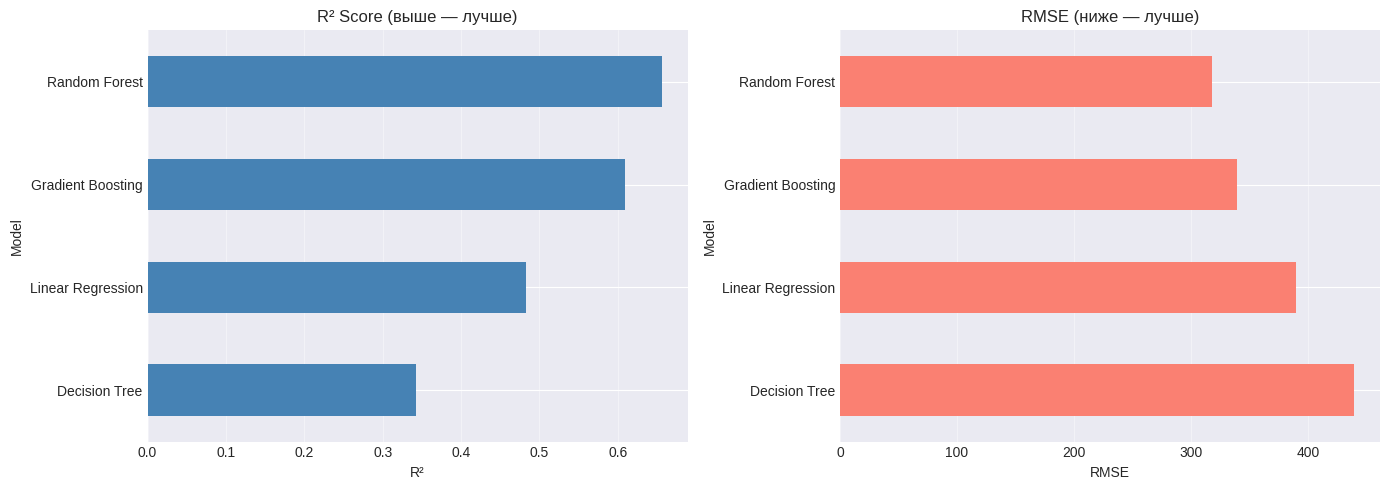

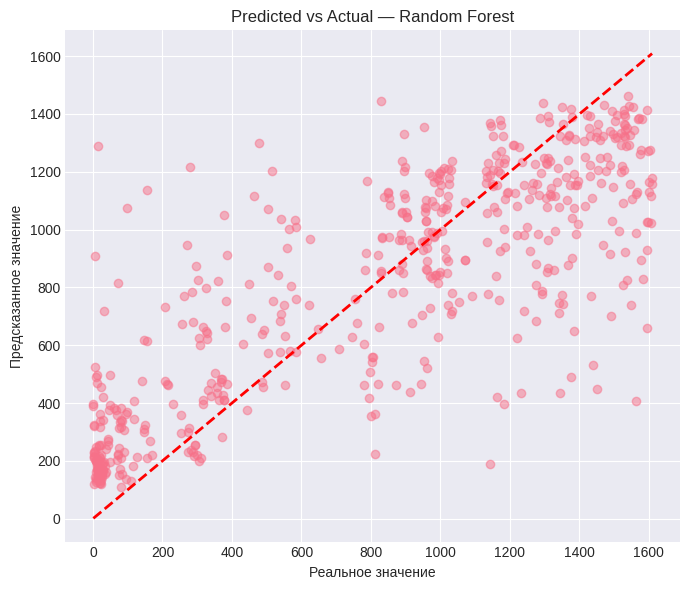

In [60]:
# сравниваем методы
reg_summary = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R²':   [lr_r2, dt_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, gb_rmse],
    'MAE':  [lr_mae,  dt_mae,  rf_mae,  gb_mae]
}).set_index('Model').round(4)

print("Сводная таблица — Регрессия:")
print(reg_summary.to_string())

best_reg = reg_summary['R²'].idxmax()
print(f"\nЛучшая модель по R²: {best_reg} ({reg_summary.loc[best_reg, 'R²']:.4f})")

# График сравнения R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_summary['R²'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('R² Score (выше — лучше)')
axes[0].set_xlabel('R²')
axes[0].grid(axis='x', alpha=0.4)

reg_summary['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('RMSE (ниже — лучше)')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

#для лучшей модели
best_pred_map = {
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}
y_best = best_pred_map[best_reg]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальное значение')
plt.ylabel('Предсказанное значение')
plt.title(f'Predicted vs Actual — {best_reg}')
plt.tight_layout()
plt.show()

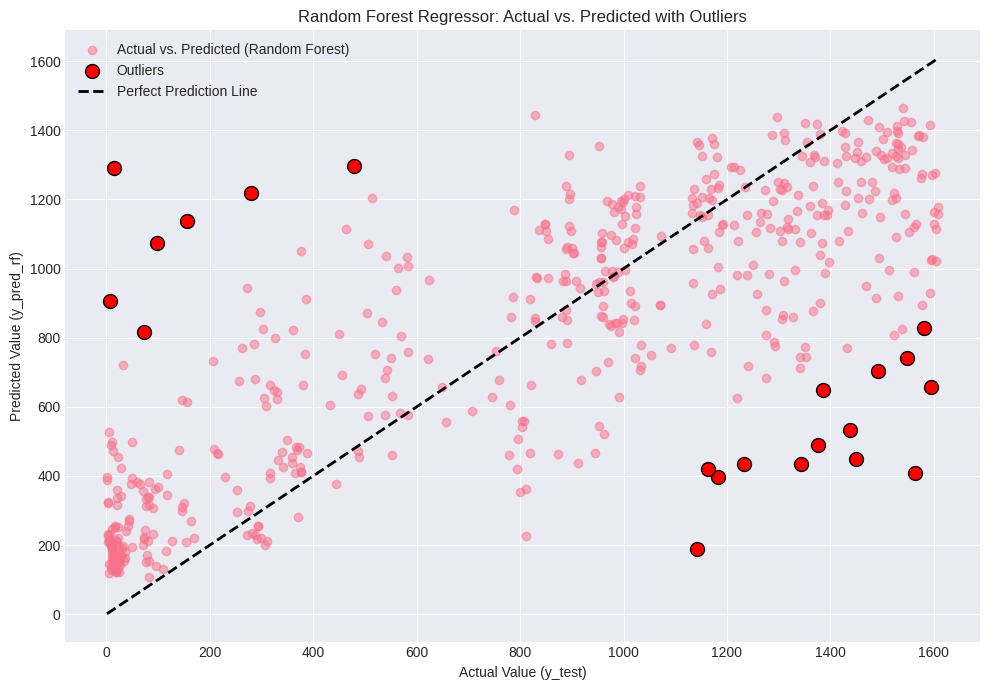


Number of outlier predictions: 21
Lower bound for residual outliers: -715.36
Upper bound for residual outliers: 726.45

--- Outlier Samples (Actual vs. Predicted) ---
      Actual    Predicted     Residual
329     1492   702.534481   789.465519
520     1563   407.574880  1155.425120
1387       7   907.407204  -900.407204
1519     156  1137.445064  -981.445064
2553    1385   648.918173   736.081827
954     1344   435.888420   908.111580
347     1594   658.130194   935.869806
494     1450   448.494231  1001.505769
479     1377   489.071289   887.928711
1970    1143   188.655524   954.344476
67      1549   739.908014   809.091986
2275    1233   434.019234   798.980766
513       72   816.757179  -744.757179
1638    1183   396.393575   786.606425
826     1438   533.116741   904.883259
2178    1163   420.871006   742.128994
1061     478  1298.156292  -820.156292
320       98  1074.947143  -976.947143
1461     279  1217.974639  -938.974639
21        14  1289.868443 -1275.868443
1029    1582 

In [61]:
# Calculate residuals (errors)
residuals = y_test - y_pred_rf

# Calculate IQR for residuals
Q1_res = residuals.quantile(0.25)
Q3_res = residuals.quantile(0.75)
IQR_res = Q3_res - Q1_res

lower_bound_res = Q1_res - 1.5 * IQR_res
upper_bound_res = Q3_res + 1.5 * IQR_res

# Identify outlier residuals
outlier_mask = (residuals < lower_bound_res) | (residuals > upper_bound_res)

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

# Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Actual vs. Predicted (Random Forest)')
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Lower bound for residual outliers: {lower_bound_res:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})
print(outlier_df.to_string())

--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---


,Actual,Predicted,Residual
1008,567,581.332389,-14.332389
1789,486,471.640103,14.359897
2648,989,989.260014,-0.260014
1460,1164,1155.414094,8.585906
1262,860,781.473058,78.526942


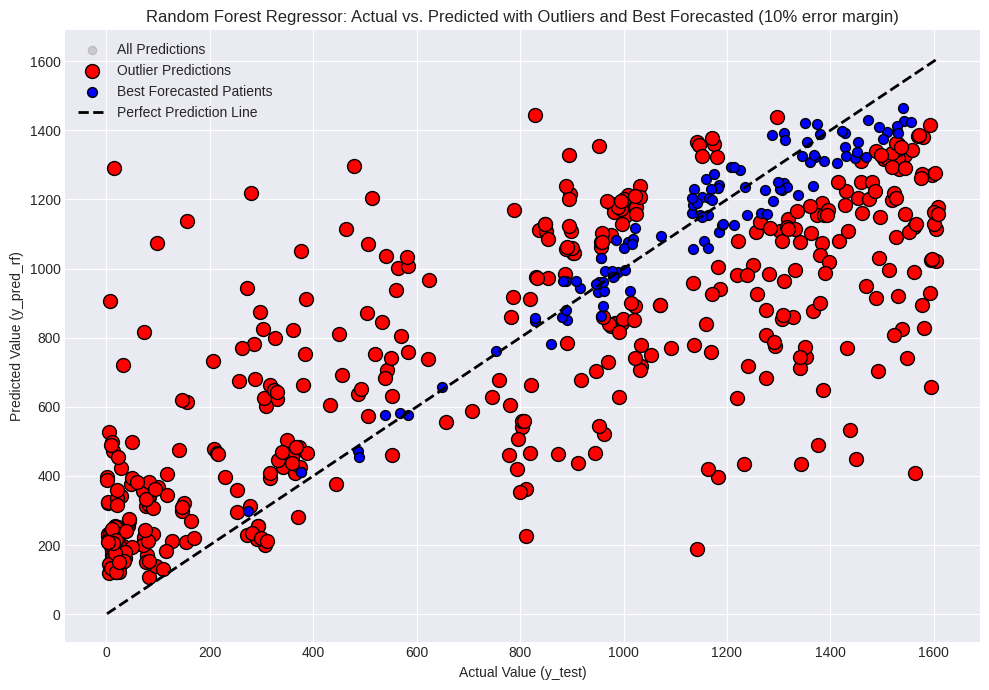


Number of outlier predictions: 429
Number of best forecasted patients: 113
Error margin for acceptable residuals: +/- 10% of actual value

--- Outlier Samples (Actual vs. Predicted) ---

--- Real Outlier Samples ---
     Actual    Predicted     Residual
0    1527.0  1325.138136   201.861864
1     464.0  1114.623766  -650.623766
2    1384.0  1074.189998   309.810002
3     376.0  1049.743573  -673.743573
4    1460.0  1249.177065   210.822935
5    1022.0   892.057446   129.942554
6     759.0   677.660589    81.339411
7     504.0   870.437312  -366.437312
8       3.0   320.753614  -317.753614
9    1033.0   779.908490   253.091510
10    745.0   629.315219   115.684781
11    828.0  1444.359861  -616.359861
12     76.0   313.477337  -237.477337
13   1545.0  1327.221461   217.778539
14   1530.0  1360.687857   169.312143
15    303.0   826.424524  -523.424524
16    812.0   224.705061   587.294939
17   1174.0  1360.856562  -186.856562
18   1580.0  1381.500371   198.499629
19   1025.0  1177.02898

In [62]:
residuals = y_test - y_pred_rf

# Define 'best forecasted patients' based on a 10% error margin
# A prediction is 'best' if its absolute error is within 10% of the actual value.
error_margin = 0.10 # 10%

# Calculate lower and upper bounds for predictions to be considered 'best'
# Predicted value should be between (Actual * (1 - error_margin)) and (Actual * (1 + error_margin))
# This implies: Actual - (Actual * error_margin) <= Predicted <= Actual + (Actual * error_margin)
# Rearranging: -(Actual * error_margin) <= Predicted - Actual <= (Actual * error_margin)
# Or: -abs(Actual * error_margin) <= Residual <= abs(Actual * error_margin)

# For each actual value in y_test, define its acceptable residual range
acceptable_residual_lower_bound = -np.abs(y_test * error_margin)
acceptable_residual_upper_bound = np.abs(y_test * error_margin)

# Identify 'best forecasted patients' based on the new error margin
best_forecasted_mask = (residuals >= acceptable_residual_lower_bound) & (residuals <= acceptable_residual_upper_bound)

# Identify 'outlier predictions' as those NOT in the best forecasted group
outlier_mask = ~best_forecasted_mask

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

best_forecasted_y_test = y_test[best_forecasted_mask]
best_forecasted_y_pred_rf = y_pred_rf[best_forecasted_mask]

# Create DataFrame for best forecasted patients
best_forecasted_df = pd.DataFrame({
    'Actual': best_forecasted_y_test,
    'Predicted': best_forecasted_y_pred_rf,
    'Residual': residuals[best_forecasted_mask]
})

print("--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---")
display(best_forecasted_df.head())

# Plotting actual vs. predicted values with outliers and best forecasted patients highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='All Predictions', color='gray') # All points in gray
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outlier Predictions', edgecolors='black')
plt.scatter(best_forecasted_y_test, best_forecasted_y_pred_rf, color='blue', s=50, label='Best Forecasted Patients', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers and Best Forecasted (10% error margin)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Number of best forecasted patients: {len(best_forecasted_y_test)}")
print(f"Error margin for acceptable residuals: +/- {error_margin*100:.0f}% of actual value")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})

# Determine the threshold for original samples based on the length of the original `data` DataFrame
original_data_length = len(data)

# Create lists to store real and SMOTE-generated outlier samples
real_outliers = []
smote_outliers = []

for original_upsampled_index, row in outlier_df.iterrows():
    if original_upsampled_index < original_data_length:
        # This index corresponds to an original sample
        real_outliers.append(row.to_dict())
    else:
        # This index corresponds to a SMOTE-generated sample
        smote_outliers.append(row.to_dict())

print("\n--- Real Outlier Samples ---")
if real_outliers:
    print(pd.DataFrame(real_outliers).to_string())
else:
    print("No real outlier samples found.")

print("\n--- SMOTE-Generated Outlier Samples ---")
if smote_outliers:
    print(pd.DataFrame(smote_outliers).to_string())
else:
    print("No SMOTE-generated outlier samples found.")

In [63]:
real_outliers_df = pd.DataFrame(real_outliers)
real_outlier_indices = real_outliers_df.index

print("Real Outlier Samples from the original `data` DataFrame:")
display(data.loc[real_outlier_indices])

Real Outlier Samples from the original `data` DataFrame:


,doctor,time,age,af,dm,ckd,copd,insult,onco,severity,...,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea,target
0,1,1152,79.0,0,1,0,0,0,0,0,...,30.7,0,84.0,7.1,213.0,2.2,1.06,8.7,117.0,0
1,1,949,61.0,1,1,0,0,0,1,1,...,34.0,0,166.0,9.4,225.0,5.8,3.61,4.4,94.0,0
2,1,1135,49.0,0,0,0,0,0,0,1,...,23.0,1,150.0,10.5,208.0,7.4,5.09,3.9,74.0,0
3,2,1524,59.0,0,0,0,0,0,0,1,...,26.5,1,142.0,5.1,58.0,5.3,3.30,4.2,86.0,0
4,2,1396,55.0,0,0,0,0,0,0,1,...,29.0,1,151.0,7.7,305.0,7.3,5.07,4.3,96.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,2,1549,68.0,0,1,0,0,0,0,1,...,45.0,0,128.0,8.0,276.0,7.5,5.42,8.5,83.0,0
215,2,1282,61.0,0,0,0,0,0,0,1,...,34.5,1,144.0,16.5,301.0,6.9,4.60,6.7,76.0,0
216,2,1019,67.0,0,0,0,0,0,1,1,...,29.0,0,109.0,11.6,221.0,5.3,3.24,6.1,43.0,0
217,2,1159,73.0,0,0,0,0,0,0,1,...,29.0,1,134.0,9.4,176.0,4.6,2.90,4.5,68.0,0


Mean SHAP for llo: 3.7868


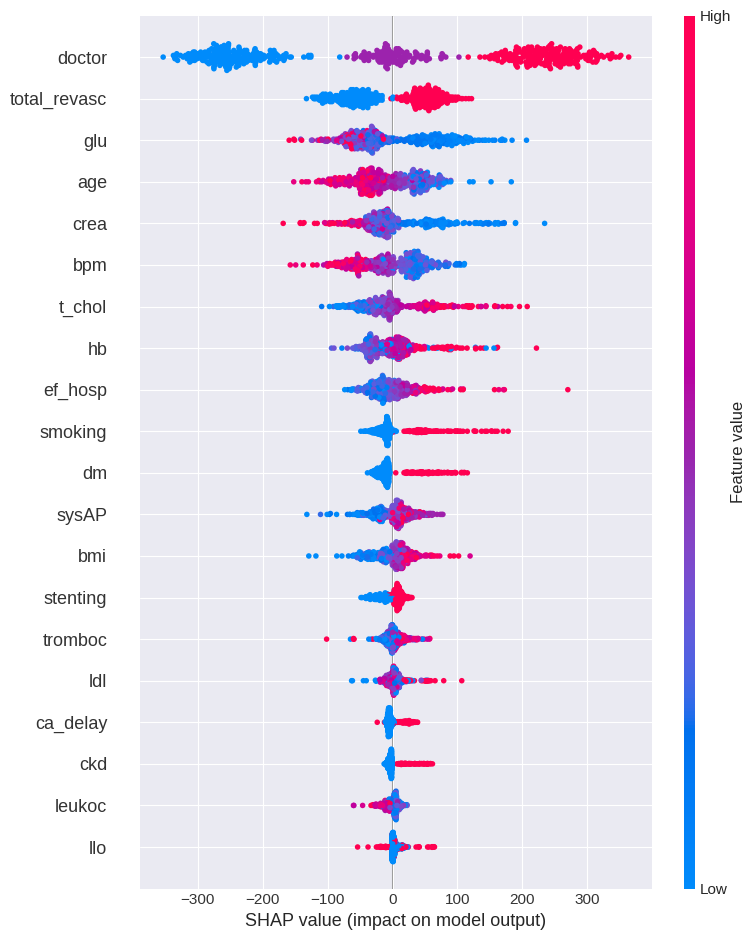

In [64]:
import shap
explainer = shap.TreeExplainer(gb_reg)
shap_values = explainer.shap_values(X_test_sc)

# Усреднённое влияние llo на вероятность result=1
llo_idx = list(X_test.columns).index('llo')
print(f"Mean SHAP for llo: {shap_values[:, llo_idx].mean():.4f}")
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

# Разъяснение SHAP-значения для 'llo' в модели регрессии

В модели `llo` (получение бесплатного лекарственного обеспечения) является фактором, который ожидаемо должен оказывать положительное влияние на пациента. SHAP-значение в `3.7868` кажется "недостаточно сильным:

1.  **Интерпретация SHAP-значения для 'llo':**
    Среднее SHAP-значение для `llo` составляет `3.7868`. Это означает, что для пациентов, получающих бесплатное лекарственное обеспечение (`llo=1`), прогнозируемое *время* в среднем **увеличивается примерно на 3.79 единицы** по сравнению с базовым предсказанием модели (или пациентами, не получающими `llo`).

3.  **"Недостаточно сильный" эффект?**
    Величина `3.79` может казаться небольшой, поэтому важно учитывать несколько аспектов:
    *   **Множество факторов:** Модель учитывает множество других факторов. `llo` является одним из них.
    *   **Согласованность с анализом выживаемости (CoxPHFitter):**
        *   Ранее модель `CoxPHFitter` показала, что `llo` имеет `exp(coef)` (отношение рисков) равное `0.26`, с 95% доверительным интервалом `[0.15, 0.46]`. Поскольку этот интервал полностью **ниже 1**, это подтверждает, что `llo` **значительно снижает риск** наступления события (например, смертности). Снижение риска означает *увеличение времени выживания*.
        *   График функции выживаемости также наглядно показал, что кривая для `llo=1` (получающие лекарство) **лежит выше** кривой для `llo=0` (не получающие лекарство), что также свидетельствует о **более высокой вероятности выживания** и, соответственно, более длительном времени до наступления события.

**Вывод:**
SHAP-значение `3.7868` для `llo` в регрессионной модели **действительно указывает на позитивный эффект**: оно предсказывает увеличение `time`, что в данном контексте означает увеличение времени выживания или отсрочку неблагоприятного события. Этот результат полностью согласуется с данными `CoxPHFitter` и графиками выживаемости, которые также показывают, что `llo` ассоциируется со сниженным риском и лучшей выживаемостью. Величина эффекта может быть не самой крупной в абсолютном выражении, но она является статистически значимой и клинически благоприятной.


SHAP values calculated for a single regression output.
Overall SHAP Summary Plot for Gradient Boosting Regressor:


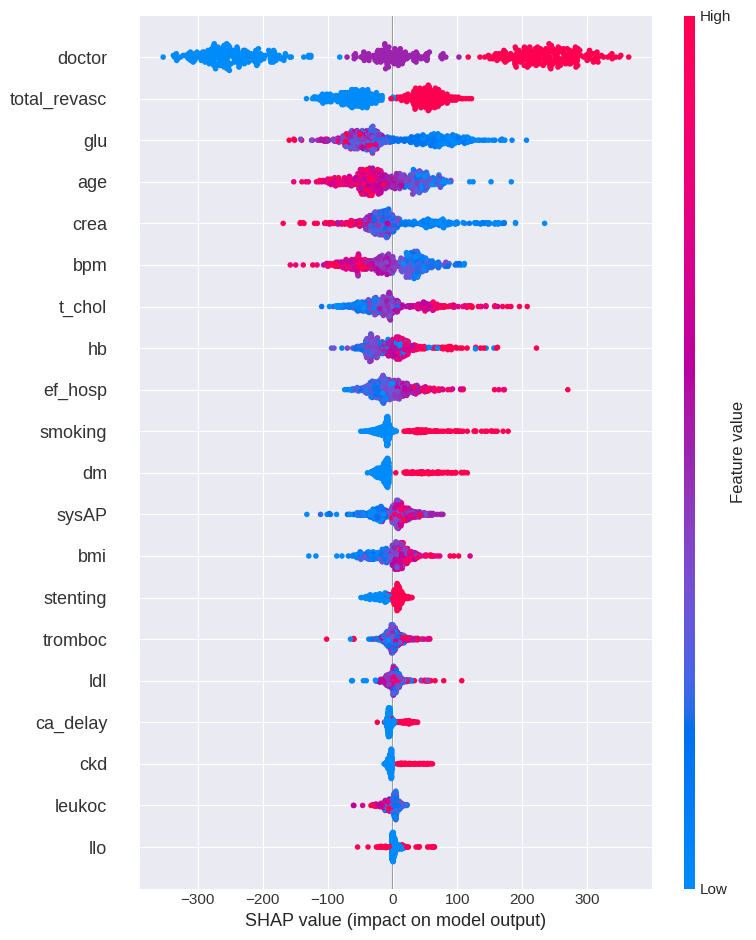


Mean SHAP value for 'llo' on predicting 'time': 3.7868
SHAP Dependence Plot for 'llo' on predicting 'time':


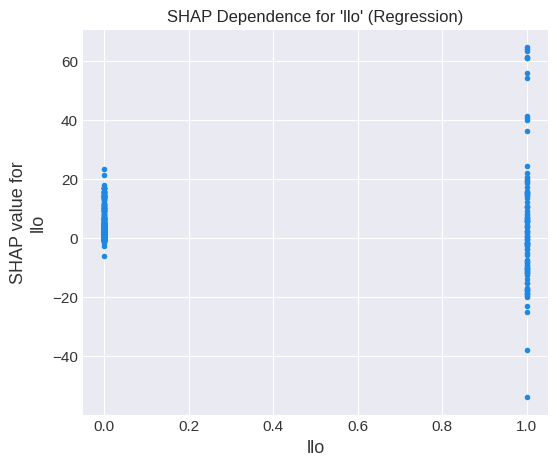

In [65]:
import shap
import matplotlib.pyplot as plt

# The model being explained is `gb_reg`, which is a GradientBoostingRegressor.
# Therefore, the SHAP values will be a 2D array (samples, features), not a 3D array for multiple classes.

# Create a SHAP explainer for the Gradient Boosting Regressor model
explainer = shap.TreeExplainer(gb_reg)

# Calculate SHAP values for the scaled test set
shap_values = explainer.shap_values(X_test_sc)

# Get the index of the 'llo' feature from the unscaled X_test DataFrame
llo_idx = list(X_test.columns).index('llo')

# For regression models, there is only one output, so no 'num_classes' to iterate over.
print(f"\nSHAP values calculated for a single regression output.")

# Overall SHAP Summary Plot for the Regression Model
print("Overall SHAP Summary Plot for Gradient Boosting Regressor:")
# Use X_test (unscaled DataFrame) for feature values in the plot for better interpretability
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

# Investigate 'llo' influence
print(f"\nMean SHAP value for 'llo' on predicting 'time': {shap_values[:, llo_idx].mean():.4f}")

# Create a SHAP dependence plot for 'llo'
print(f"SHAP Dependence Plot for 'llo' on predicting 'time':")
shap.dependence_plot('llo', shap_values, X_test, feature_names=X_test.columns, interaction_index=None, show=False)
plt.title(f"SHAP Dependence for 'llo' (Regression)")
plt.show()

SHAP Interaction Plot for 'llo' and 'age':


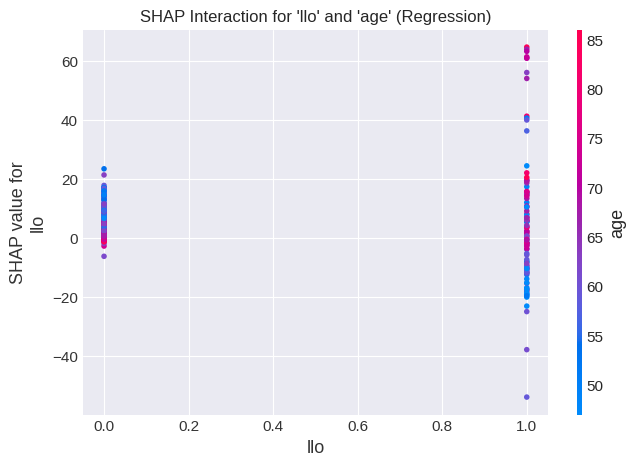


Number of patients with negative SHAP for 'llo' and llo=1.0: 48

Characteristics of patients with negative SHAP for 'llo' and llo=1.0:


,doctor,age,af,dm,ckd,copd,insult,onco,severity,nstemi,...,pulm_cong,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea
701,2,47.219178,0,1,1,0,0,0,1,1,...,0,32.000000,1,141.000000,12.4,272.000000,3.400000,1.900000,5.000000,72.000000
18,2,57.000000,0,0,0,0,0,0,1,0,...,0,31.000000,0,152.000000,9.6,256.000000,5.100000,3.000000,6.800000,78.000000
1154,2,51.334247,0,1,1,0,0,0,1,1,...,0,45.000000,0,145.000000,7.8,197.000000,4.600000,2.560000,10.700000,103.000000
793,2,59.000000,0,1,0,0,0,0,1,0,...,0,36.400000,1,153.000000,18.5,334.000000,5.100000,2.190000,12.000000,70.000000
1420,2,76.000000,1,1,0,0,0,0,0,0,...,0,29.300000,0,117.000000,5.7,141.000000,3.200000,1.520000,5.600000,63.000000
1117,2,70.000000,1,0,0,0,0,0,0,0,...,0,32.800000,0,141.000000,8.6,255.000000,3.400000,1.850000,4.800000,62.000000
503,2,63.000000,0,1,0,0,1,0,0,0,...,0,31.800000,0,126.000000,7.2,145.000000,5.300000,3.240000,7.000000,105.000000
581,2,58.000000,0,1,0,0,0,0,1,0,...,0,23.000000,1,130.000000,9.3,321.000000,6.300000,3.580000,6.000000,49.000000
781,2,60.000000,0,1,0,0,0,0,0,0,...,0,31.100000,0,150.000000,9.7,239.000000,6.200000,3.100000,9.300000,83.000000
596,2,44.000000,0,0,0,0,0,0,1,0,...,0,34.000000,0,151.000000,9.1,220.000000,7.600000,5.140000,4.600000,75.000000



Corresponding SHAP values for 'llo' for these patients:
[-16.78950772  -9.99901155  -1.72323359  -7.27923478  -1.64247263
  -2.29376307  -2.45120484 -10.34476218 -11.60674191 -10.31204667
 -19.53805497  -2.65979956 -11.70857738 -37.78627835 -13.85234102
  -0.67735211 -17.4672138   -8.13253481 -11.88652268 -17.28479102
  -5.70852659  -5.21193274 -12.38441794  -3.74684014 -11.09862304
 -18.53314562 -15.17046902  -9.25962025 -19.98112889  -1.88475866
  -1.61323066  -3.63199655  -7.87866169 -10.65842985 -15.27047439
  -1.66507405 -53.84303904  -0.43739028 -23.04085103  -9.50663578
 -17.42357781 -19.06605698  -8.58557737 -10.30660264 -18.01301144
 -24.90571095  -0.44687151 -19.06605698]

Descriptive statistics for these patients:


,doctor,age,af,dm,ckd,copd,insult,onco,severity,nstemi,...,pulm_cong,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea
count,48.0,48.000000,48.000000,48.000000,48.000000,48.0,48.000000,48.0,48.000000,48.000000,...,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,2.0,57.733081,0.104167,0.395833,0.062500,0.0,0.104167,0.0,0.791667,0.250000,...,0.041667,29.141555,0.375000,145.422850,10.777083,243.932441,5.022253,3.055012,6.368461,76.574515
std,0.0,10.879831,0.308709,0.494204,0.244623,0.0,0.308709,0.0,0.410414,0.437595,...,0.201941,5.732699,0.489246,16.550625,4.520132,50.762515,1.565157,1.246169,2.360662,19.026642
min,2.0,32.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,21.700000,0.000000,99.000000,4.500000,141.000000,1.600000,0.770000,2.160000,49.000000
25%,2.0,50.750685,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.000000,...,0.000000,25.650000,0.000000,136.000000,7.800000,203.750000,3.900000,2.250000,4.900000,63.750000
50%,2.0,58.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.000000,...,0.000000,28.000000,0.000000,146.000000,9.800000,242.500000,5.100000,3.110000,5.550000,73.500000
75%,2.0,63.250000,0.000000,1.000000,0.000000,0.0,0.000000,0.0,1.000000,0.250000,...,0.000000,32.000000,1.000000,158.000000,12.950000,278.112502,5.900000,3.870000,7.075000,83.750000
max,2.0,77.000000,1.000000,1.000000,1.000000,0.0,1.000000,0.0,1.000000,1.000000,...,1.000000,51.400000,1.000000,183.000000,26.700000,389.000000,8.500000,5.900000,13.200000,151.000000


In [79]:
print("SHAP Interaction Plot for 'llo' and 'age':")
shap.dependence_plot('llo', shap_values, X_test, feature_names=X_test.columns, interaction_index='age', show=False)
plt.title("SHAP Interaction for 'llo' and 'age' (Regression)")
plt.show()

# Analyze patients with negative SHAP value for 'llo' and llo=1.0

llo_idx = list(X_test.columns).index('llo') # Ensure llo_idx is correctly retrieved

# Filter for negative SHAP values for 'llo'
negative_llo_shap_mask = shap_values[:, llo_idx] < 0

# Filter for 'llo' feature value equal to 1.0
llo_is_one_mask = X_test['llo'] == 1.0

# Combine both conditions
target_patients_mask = negative_llo_shap_mask & llo_is_one_mask

# Get the subset of X_test for these patients
target_patients_data = X_test[target_patients_mask]

# Get the SHAP values for these specific patients and the 'llo' feature
target_patients_llo_shap = shap_values[target_patients_mask, llo_idx]

print(f"\nNumber of patients with negative SHAP for 'llo' and llo=1.0: {len(target_patients_data)}")

if not target_patients_data.empty:
    print("\nCharacteristics of patients with negative SHAP for 'llo' and llo=1.0:")
    display(target_patients_data)
    print("\nCorresponding SHAP values for 'llo' for these patients:")
    print(target_patients_llo_shap)
    print("\nDescriptive statistics for these patients:")
    display(target_patients_data.describe())
else:
    print("No patients found matching the criteria (negative SHAP for 'llo' and llo=1.0).")

In [80]:
# Get SHAP values for the target patients across all features
target_patients_all_shap = shap_values[target_patients_mask, :]

# Calculate the mean SHAP value for each feature for these patients
mean_shap_per_feature = np.mean(target_patients_all_shap, axis=0)

# Create a DataFrame for better readability
mean_shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_shap_value': mean_shap_per_feature
})

# Filter for features with high positive mean SHAP values (excluding 'llo' itself)
high_positive_shap_features = mean_shap_df[
    (mean_shap_df['mean_shap_value'] > 0) &
    (mean_shap_df['feature'] != 'llo')
].sort_values(by='mean_shap_value', ascending=False)

print("\nFeatures with high positive mean SHAP values for patients with negative 'llo' SHAP and llo=1.0:")
display(high_positive_shap_features)


Features with high positive mean SHAP values for patients with negative 'llo' SHAP and llo=1.0:


,feature,mean_shap_value
0,doctor,220.139413
16,total_revasc,28.050130
1,age,25.662773
28,glu,19.215736
23,hb,16.736426
29,crea,15.097840
3,dm,10.683314
22,smoking,10.168625
17,ef_hosp,8.824493
15,stenting,5.774707


# Анализ влияния LLO на время дожития "молодой" группы

Verification of SHAP Interaction Between 'llo' and 'age'

We observed from the SHAP interaction plot that for younger patients (small age),  having 'llo' (receiving free medication) appears to lower the predicted time (negative outcome).
This is counterintuitive since we'd generally expect medication access to improve outcomes.

We'll verify this finding using three different methods:
1. Stratified Analysis by Age Groups
2. Cox Model with Interaction Term
3. Partial Dependence Plots with Interaction


In [83]:
!pip install lifelines -q

In [92]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
import shap
from lifelines import CoxPHFitter
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


In [93]:
# Load the data
data_link = "https://github.com/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/raw/refs/heads/main/med_dataset_cardio.xlsx"
data = pd.read_excel(data_link, header=0)

# Strip whitespace from all column names
data.columns = data.columns.str.strip()

# Rename columns
data.rename(columns={
    "0_na, 1_mi": "severity",
    "0_no, 1_ther, 2_card": "doctor"
}, inplace=True)

# Drop columns if they exist
columns_to_drop = []
for col in ["card", "na", "dmonit"]:
    if col in data.columns:
        columns_to_drop.append(col)

if columns_to_drop:
    data.drop(columns=columns_to_drop, inplace=True)

# Set target variable
if "result_cvd" in data.columns:
    data["target"] = data["result"]
    data.drop(columns=["result", "result_cvd"], inplace=True)

In [94]:
df = data.copy()

# Upsample minority class using SMOTE
X = df.drop('target', axis=1)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

# Scale data - but keep the original DataFrames for interpretation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [95]:
explainer = shap.TreeExplainer(gb_reg)
shap_values = explainer.shap_values(X_test_sc)


Stratified Analysis by Age Groups:
  Age Group  Mean Time (llo=1)  Mean Time (llo=0)  Difference       p-value
0     Young        1146.497854        1053.784370   92.713484  1.015417e-02
1    Middle        1125.878981         704.589779  421.289202  7.972447e-20
2       Old        1056.363636         535.390681  520.972955  3.507164e-15


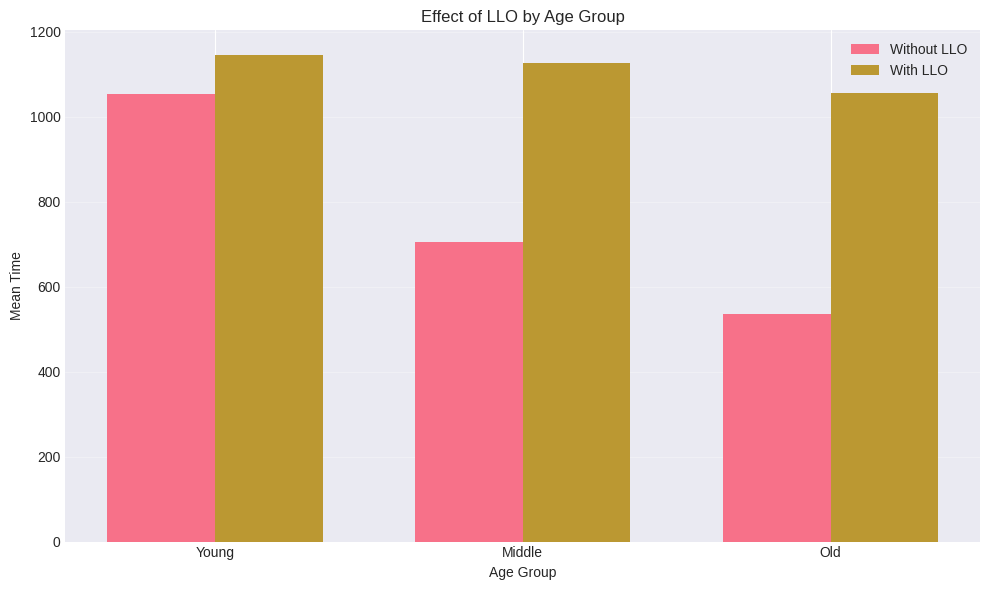

In [96]:
# ## Method 1: Stratified Analysis by Age Groups
#
# We'll divide patients into age groups and compare the effect of 'llo' within each group.

# %% [code]
# Create age groups (tertiles)
age_groups = pd.qcut(df_upsampled['age'], q=3, labels=['Young', 'Middle', 'Old'])
df_upsampled['age_group'] = age_groups

# For each age group, compare time between llo=0 and llo=1
results = []
for group in ['Young', 'Middle', 'Old']:
    group_data = df_upsampled[df_upsampled['age_group'] == group]

    # Mean time for patients with and without llo
    time_with_llo = group_data[group_data['llo'] == 1]['time'].mean()
    time_without_llo = group_data[group_data['llo'] == 0]['time'].mean()

    # Statistical significance test
    t_stat, p_value = stats.ttest_ind(
        group_data[group_data['llo'] == 1]['time'],
        group_data[group_data['llo'] == 0]['time'],
        nan_policy='omit'
    )

    results.append({
        'Age Group': group,
        'Mean Time (llo=1)': time_with_llo,
        'Mean Time (llo=0)': time_without_llo,
        'Difference': time_with_llo - time_without_llo,
        'p-value': p_value
    })

stratified_results = pd.DataFrame(results)
print("\nStratified Analysis by Age Groups:")
print(stratified_results)

# Visualize the results
plt.figure(figsize=(10, 6))
x = np.arange(len(stratified_results))
width = 0.35

plt.bar(x - width/2, stratified_results['Mean Time (llo=0)'], width, label='Without LLO')
plt.bar(x + width/2, stratified_results['Mean Time (llo=1)'], width, label='With LLO')

plt.xlabel('Age Group')
plt.ylabel('Mean Time')
plt.title('Effect of LLO by Age Group')
plt.xticks(x, stratified_results['Age Group'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



Cox Model with LLO*Age Interaction:


<lifelines.CoxPHFitter: fitted with 2708 total observations, 1354 right-censored observations>
             duration col = 'time'
                event col = 'target'
      baseline estimation = breslow
   number of observations = 2708
number of events observed = 1354
   partial log-likelihood = -9703.47
         time fit was run = 2026-05-13 18:55:49 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
llo                 -1.30      0.27      1.02           -3.31            0.70                0.04                2.02
age                  0.04      1.04      0.00            0.04            0.05                1.04                1.05
ef_hosp             -0.03      0.97      0.00           -0.04           -0.02                0.96                0.98
crea                 0.00      1.00      0.00            0.00            0.00                1.00                1.00
llo_age_interaction -0.01      0.99      0.02           -0.04            0.02                0.96                1.02

                     cmp to     z      p  -log2(p)
covariate                                         
llo                    0.00 -1.27   0.20      2.30
age                    0.00 16.06 <0.005    190.40
ef_hosp                0.00 -6.88 <0.005     37.29
crea                   0.00  4.07 <0.005     14.38
llo_age_interaction    0.00 -0.73   0.47      1.10
---
Concordance = 0.72
Partial AIC = 19416.93
log-likelihood ratio test = 913.45 on 5 df
-log2(p) of ll-ratio test = 646.07

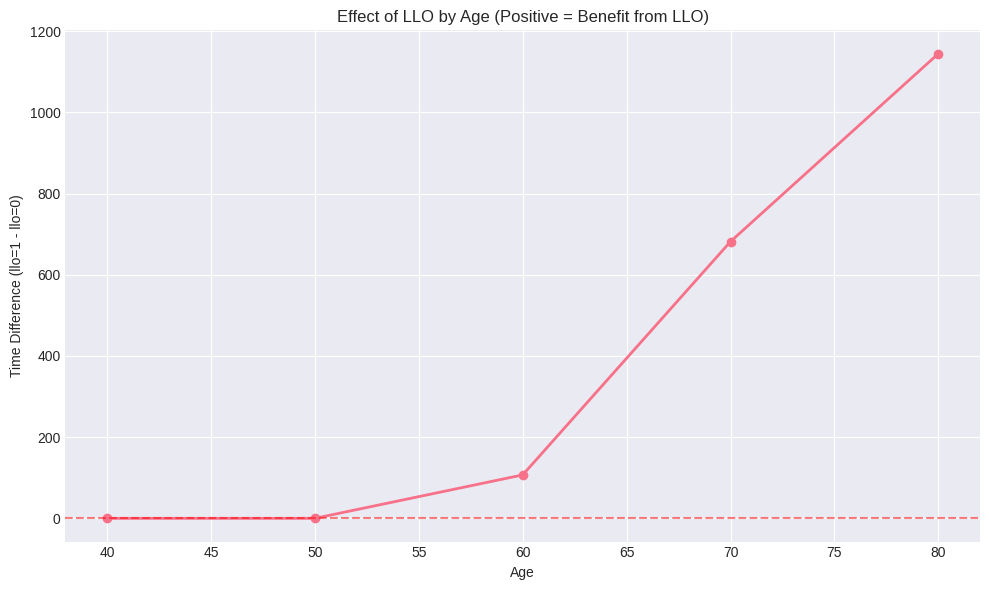

In [97]:
# ## Method 2: Cox Model with Interaction Term

# %% [code]
# Prepare data with interaction term
cph_data = df_upsampled[['time', 'target', 'llo', 'age', 'ef_hosp', 'crea']].copy()
cph_data['llo_age_interaction'] = cph_data['llo'] * cph_data['age']

# Fit Cox model with interaction
cph_interaction = CoxPHFitter()
cph_interaction.fit(cph_data, duration_col='time', event_col='target')

# Print summary to see if interaction term is significant
print("\nCox Model with LLO*Age Interaction:")
cph_interaction.print_summary()

# Create hypothetical patients with different ages and llo status
ages = [40, 50, 60, 70, 80]
predictions = []

# Determine the maximum observed time for fallback
max_observed_time = df_upsampled['time'].max()

for age in ages:
    # Create a base patient with median values for other features
    base_data = cph_data.drop(columns=['time', 'target']).median().to_frame().T
    base_data['age'] = age

    # llo=0
    pred_llo_0 = base_data.copy()
    pred_llo_0['llo'] = 0
    pred_llo_0['llo_age_interaction'] = 0 * age

    # llo=1
    pred_llo_1 = base_data.copy()
    pred_llo_1['llo'] = 1
    pred_llo_1['llo_age_interaction'] = 1 * age

    # Get median survival time
    median_time_llo_0 = None
    median_time_llo_1 = None

    try:
        sf_llo_0 = cph_interaction.predict_survival_function(pred_llo_0).iloc[:, 0]
        # If survival probability never drops below 0.5, use max_observed_time
        if not sf_llo_0[sf_llo_0 <= 0.5].empty:
            median_time_llo_0 = sf_llo_0[sf_llo_0 <= 0.5].index.min()
        else:
            median_time_llo_0 = max_observed_time # Fallback
    except Exception as e_llo0:
        print(f"Warning: Could not calculate median time for llo=0 at age {age}. Error: {e_llo0}")
        median_time_llo_0 = max_observed_time # Fallback on error

    try:
        sf_llo_1 = cph_interaction.predict_survival_function(pred_llo_1).iloc[:, 0]
        # If survival probability never drops below 0.5, use max_observed_time
        if not sf_llo_1[sf_llo_1 <= 0.5].empty:
            median_time_llo_1 = sf_llo_1[sf_llo_1 <= 0.5].index.min()
        else:
            median_time_llo_1 = max_observed_time # Fallback
    except Exception as e_llo1:
        print(f"Warning: Could not calculate median time for llo=1 at age {age}. Error: {e_llo1}")
        median_time_llo_1 = max_observed_time # Fallback on error

    predictions.append({
        'age': age,
        'median_time_llo_0': median_time_llo_0,
        'median_time_llo_1': median_time_llo_1,
        'time_difference': (median_time_llo_1 - median_time_llo_0) if median_time_llo_0 is not None and median_time_llo_1 is not None else None
    })

predictions_df = pd.DataFrame(predictions).dropna()

# Plot the interaction effect
plt.figure(figsize=(10, 6))
plt.plot(predictions_df['age'], predictions_df['time_difference'], 'o-', linewidth=2)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Time Difference (llo=1 - llo=0)')
plt.title('Effect of LLO by Age (Positive = Benefit from LLO)')
plt.grid(True)
plt.tight_layout()
plt.show()

Error calculating partial dependence: index 1 is out of bounds for axis 0 with size 1
Falling back to manual grid calculation.


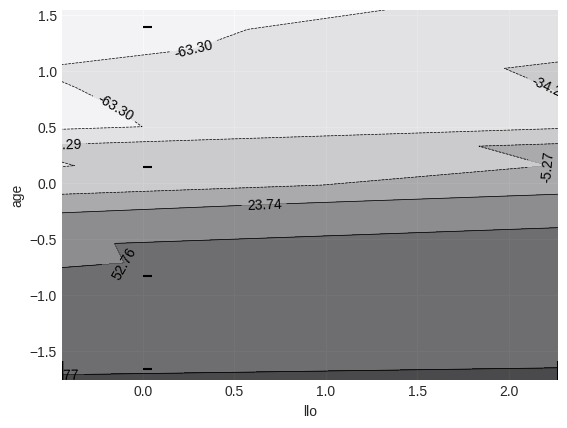

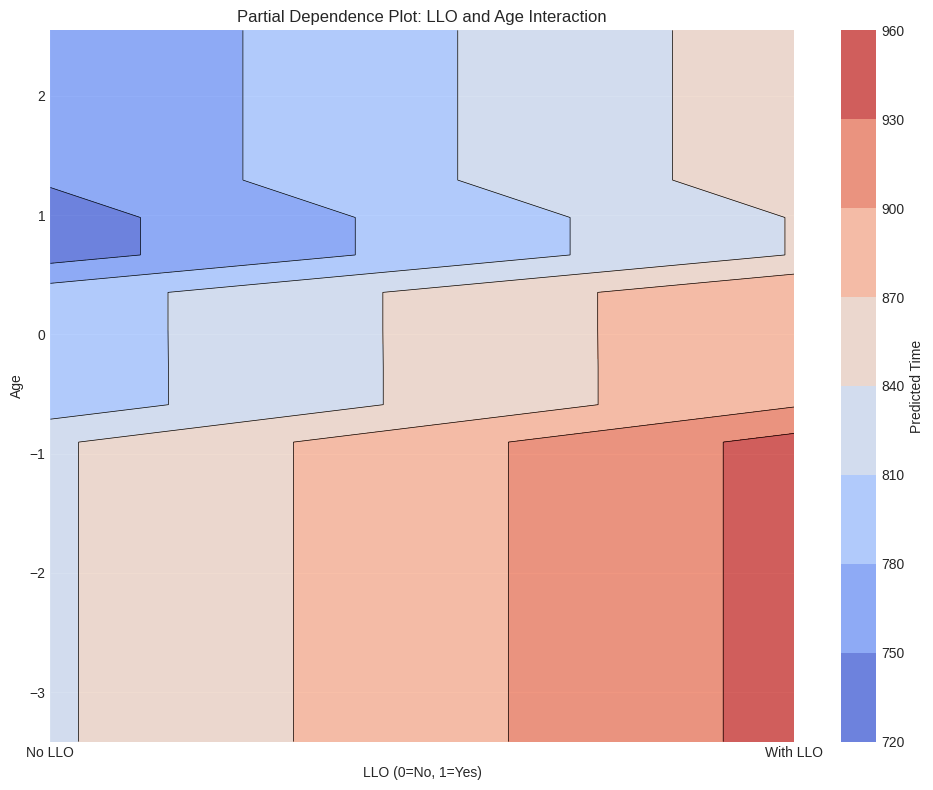

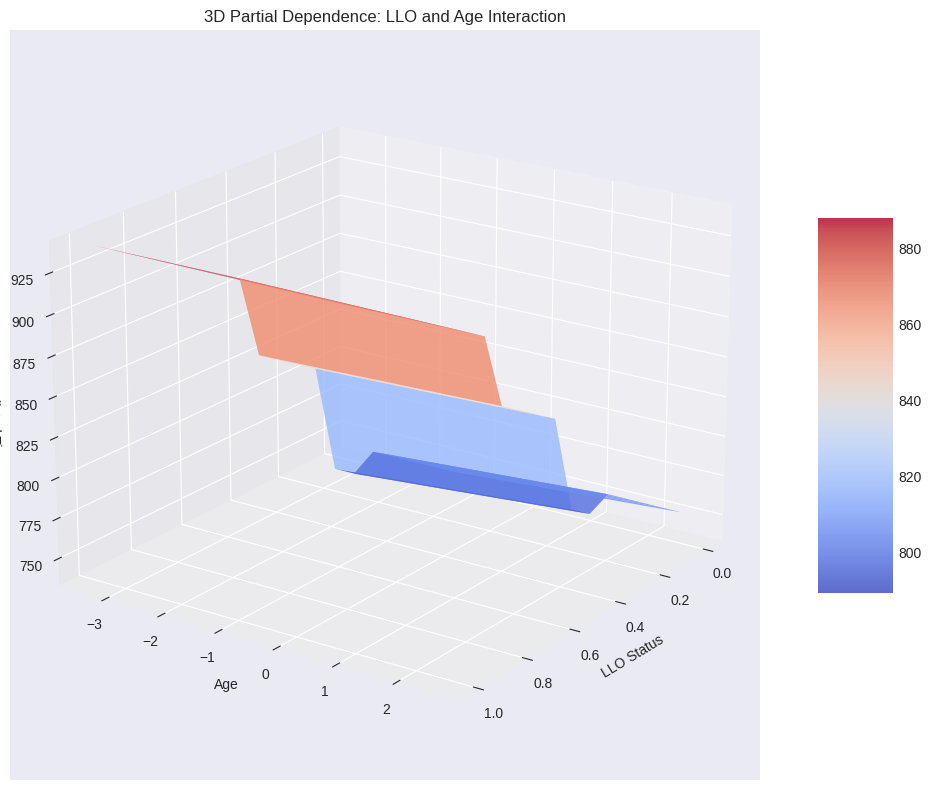

In [105]:
# ## Method 3: Partial Dependence Plots with Interaction

# Convert scaled training data back to DataFrame with original column names
X_train_sc_df = pd.DataFrame(X_train_sc, columns=original_gb_reg_features)

# Calculate partial dependence for the interaction using PartialDependenceDisplay
try:
    # Use the appropriate arguments for the installed scikit-learn version
    display = PartialDependenceDisplay.from_estimator(
        gb_reg,
        X_train_sc_df,
        features=[('llo', 'age')],
        grid_resolution=20,
        kind='average',
        n_jobs=2
    )

    # Extract the partial dependence values and grid points from the display object
    llo_values = display.axes_[0] # Grid points for the first feature ('llo')
    age_values = display.axes_[1] # Grid points for the second feature ('age')
    pdp_values = display.pd_values_[0] # Partial dependence values (2D array)

except Exception as e:
    print(f"Error calculating partial dependence: {e}")
    print("Falling back to manual grid calculation.")

    # Manual calculation of partial dependence (fallback)
    llo_values = np.array([0, 1]) # Explicitly set for binary feature
    age_values = np.linspace(X_train_sc_df['age'].min(), X_train_sc_df['age'].max(), 20)

    pdp_values = np.zeros((len(llo_values), len(age_values)))
    for i, llo_val in enumerate(llo_values):
        for j, age_val in enumerate(age_values):
            # Create a dummy dataset with this llo and age, other features at median
            X_dummy = X_train_sc_df.median().to_frame().T
            X_dummy['llo'] = llo_val
            X_dummy['age'] = age_val
            # Ensure X_dummy has the same columns as X_train_sc_df and in the same order
            X_dummy = X_dummy[X_train_sc_df.columns]
            pdp_values[i, j] = gb_reg.predict(X_dummy)[0]

# Create the interaction plot (2D Contour Plot)
fig, ax = plt.subplots(figsize=(10, 8))
# Create meshgrid where XX corresponds to LLO values (X-axis) and YY corresponds to Age values (Y-axis)
XX, YY = np.meshgrid(llo_values, age_values)
# Z for contourf should have shape (len(Y), len(X)), so we transpose pdp_values
ZZ = pdp_values.T

# Plot the surface
surf = ax.contourf(XX, YY, ZZ, cmap='coolwarm', alpha=0.8)
ax.contour(XX, YY, ZZ, colors='black', linewidths=0.5)

# Add colorbar
cbar = fig.colorbar(surf, ax=ax)
cbar.set_label('Predicted Time')

ax.set_xlabel('LLO (0=No, 1=Yes)')
ax.set_ylabel('Age')
ax.set_title('Partial Dependence Plot: LLO and Age Interaction')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No LLO', 'With LLO'])
plt.tight_layout()
plt.show()

# Create a 3D visualization for better understanding
try:
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # For plot_surface, X_grid, Y_grid, Z_grid should all have the same shape (M, N)
    # If llo_values are on X and age_values are on Y, then X_grid, Y_grid are already prepared by meshgrid
    X_grid, Y_grid = np.meshgrid(llo_values, age_values)
    Z_grid = pdp_values.T # Transpose needed for consistency with meshgrid and how plot_surface expects it

    # Plot surface
    surf = ax.plot_surface(X_grid, Y_grid, Z_grid, cmap='coolwarm', alpha=0.8)
    ax.set_xlabel('LLO Status')
    ax.set_ylabel('Age')
    ax.set_zlabel('Predicted Time')
    ax.set_title('3D Partial Dependence: LLO and Age Interaction')
    ax.view_init(elev=20, azim=35)

    # Add colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Could not create 3D plot. mpl_toolkits.mplot3d not available.")

# Оценка функции выживаемости

In [67]:
!pip install lifelines -q

In [68]:
from lifelines import CoxPHFitter

# Подготовка данных
cph_data = df[['time', 'target', 'llo', 'age', 'ef_hosp', 'crea']].dropna()

# Обучение модели
cph = CoxPHFitter()
cph.fit(cph_data, duration_col='time', event_col='target')

# Вывод результатов
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1506 total observations, 1354 right-censored observations>
             duration col = 'time'
                event col = 'target'
      baseline estimation = breslow
   number of observations = 1506
number of events observed = 152
   partial log-likelihood = -1001.28
         time fit was run = 2026-05-13 17:36:28 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
llo       -1.34      0.26      0.29           -1.91           -0.77                0.15                0.46
age        0.06      1.06      0.01            0.05            0.08                1.05                1.08
ef_hosp   -0.04      0.96      0.01           -0.06           -0.01                0.94                0.99
crea       0.01      1.01      0.00            0.00            0.01                1.00                1.01

           cmp to     z      p  -log2(p)
covariate                               
llo          0.00 -4.59 <0.005     17.79
age          0.00  8.25 <0.005     52.44
ef_hosp      0.00 -3.05 <0.005      8.77
crea         0.00  4.10 <0.005     14.57
---
Concordance = 0.78
Partial AIC = 2010.56
log-likelihood ratio test = 171.75 on 4 df
-log2(p) of ll-ratio test = 117.45

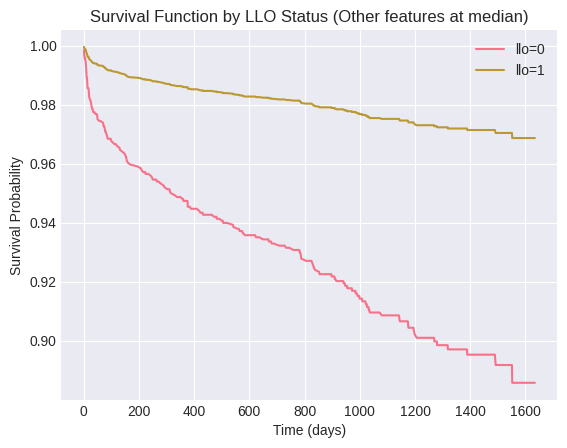

In [69]:
from lifelines import CoxPHFitter

# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

median_data = cph_data.drop(columns=['time', 'target']).median().to_frame().T


# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function
cph.predict_survival_function(plot_data).plot()
plt.title('Survival Function by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

**Интерпретация графика функции выживаемости по статусу LLO:**

Survival function говорит о «накопленном успехе» (кто остался). Этот график функции выживаемости демонстрирует прогнозируемую вероятность выживания с течением времени для двух групп пациентов, различающихся только по статусу `llo` (факт получения лекарственного обеспечения):

*   **Красная линия (llo=0):** Представляет пациентов, которые **не** получают бесплатное лекарственное обеспечение. Кривая начинается со 100% выживаемости и постепенно снижается, показывая, как вероятность выживания уменьшается со временем.

*   **Желтая линия (llo=1):** Представляет пациентов, которые **получают** бесплатное лекарственное обеспечение.

**Вывод:** Визуально видно, что группа пациентов с `llo=1` (получающая льготное лекарственное обеспечение) имеет **более высокую вероятность выживания** по сравнению с группой `llo=0` (не получающей такое обеспечение). Это означает, что получение бесплатного лекарственного обеспечения после выписки ассоциируется с увеличением времени до наступления события (например, смерти) и, следовательно, с улучшением прогноза выживаемости, при условии, что другие факторы остаются на среднем уровне.

In [70]:
llo_hazard_ratio_lower_ci = cph.summary.loc['llo', 'exp(coef) lower 95%']
llo_hazard_ratio_upper_ci = cph.summary.loc['llo', 'exp(coef) upper 95%']

print(f"'llo' hazard ratio 95% CI: [{llo_hazard_ratio_lower_ci:.2f}, {llo_hazard_ratio_upper_ci:.2f}]")

'llo' hazard ratio 95% CI: [0.15, 0.46]


95% доверительный интервал для отношения рисков «llo» составляет [0,15, 0,46].

Это означает, что для пациентов, получающих «llo», риск события (вероятная смертность) оценивается в пределах от 15% до 46% от риска для пациентов, не получающих «llo», при прочих равных условиях. Поскольку этот интервал полностью ниже 1, это подтверждает, что получение «llo» значительно связано со сниженным риском (т.е., с увеличением выживаемости или лучшим исходом).

# Классификация для поиска паттернов риска

In [71]:
X_reg = df_upsampled.drop(['time', 'target'], axis=1)
y_reg = df_upsampled['time']

rf_reg_full = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg_full.fit(X_reg, y_reg)

y_pred_time = rf_reg_full.predict(X_reg)
residuals = y_reg - y_pred_time

print("RandomForestRegressor trained and residuals calculated.")

RandomForestRegressor trained and residuals calculated.



Calculate the Interquartile Range (IQR) of the residuals, define lower and upper bounds for outlier detection, and then create a new binary feature in `df_upsampled` to mark these outliers.



In [72]:
Q1_res = residuals.quantile(0.25)
Q3_res = residuals.quantile(0.75)
IQR_res = Q3_res - Q1_res

lower_bound_res = Q1_res - 1.5 * IQR_res
upper_bound_res = Q3_res + 1.5 * IQR_res

# Identify outlier residuals
outlier_mask = (residuals < lower_bound_res) | (residuals > upper_bound_res)

df_upsampled['is_time_prediction_outlier'] = outlier_mask.astype(int)

print(f"Lower Bound for Residual Outliers: {lower_bound_res:.2f}")
print(f"Upper Bound for Residual Outliers: {upper_bound_res:.2f}")
print(f"Number of samples identified as time prediction outliers: {df_upsampled['is_time_prediction_outlier'].sum()}")
print("df_upsampled updated with 'is_time_prediction_outlier' feature.")

Lower Bound for Residual Outliers: -482.93
Upper Bound for Residual Outliers: 476.24
Number of samples identified as time prediction outliers: 63
df_upsampled updated with 'is_time_prediction_outlier' feature.


Prepare the augmented `df_upsampled` for classification by separating features and the target, performing a train-test split, and scaling the numerical features. The `X_clf` will now include the newly created `is_time_prediction_outlier` feature.



In [73]:
X_clf = df_upsampled.drop(['target','time'], axis=1)
y_clf = df_upsampled['target']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_csc = scaler_c.fit_transform(X_train_c)
X_test_csc  = scaler_c.transform(X_test_c)

print(f"Train: {X_train_c.shape}  |  Test: {X_test_c.shape}")
print(f"Доля в train: {y_train_c.mean():.2%}")
print(f"Доля в test:  {y_test_c.mean():.2%}")

Train: (2166, 31)  |  Test: (542, 31)
Доля в train: 50.00%
Доля в test:  50.00%


Train the `RandomForestClassifier` (which was previously identified as the best model) using the augmented `X_train_csc` and `y_train_c` data, including the new `is_time_prediction_outlier` feature.


Random Forest (100 деревьев, max_depth=10)
  Accuracy  = 0.9354
  Precision = 0.9069
  Recall    = 0.9705
  F1-Score  = 0.9376
  ROC-AUC   = 0.9818


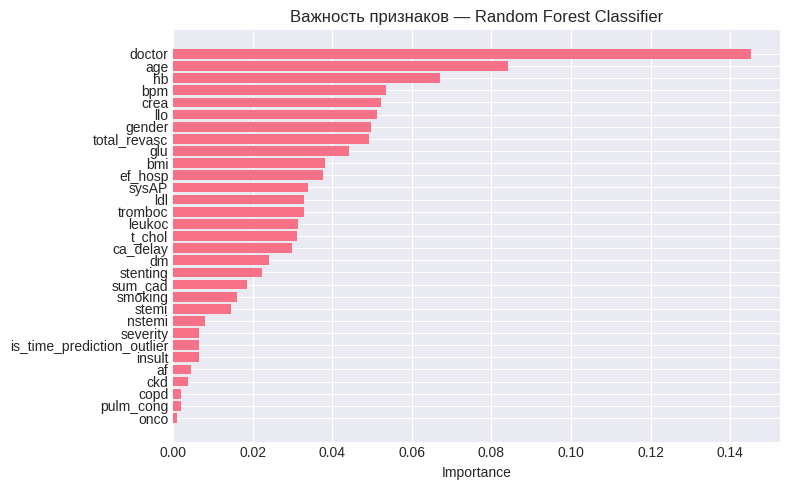

In [74]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=37, max_depth=10)
rf_clf.fit(X_train_csc, y_train_c)

y_pred_rf_c  = rf_clf.predict(X_test_csc)
y_proba_rf_c = rf_clf.predict_proba(X_test_csc)[:, 1]

rf_c_acc  = accuracy_score(y_test_c, y_pred_rf_c)
rf_c_prec = precision_score(y_test_c, y_pred_rf_c)
rf_c_rec  = recall_score(y_test_c, y_pred_rf_c)
rf_c_f1   = f1_score(y_test_c, y_pred_rf_c)
rf_c_auc  = roc_auc_score(y_test_c, y_proba_rf_c)

print("Random Forest (100 деревьев, max_depth=10)")
print(f"  Accuracy  = {rf_c_acc:.4f}")
print(f"  Precision = {rf_c_prec:.4f}")
print(f"  Recall    = {rf_c_rec:.4f}")
print(f"  F1-Score  = {rf_c_f1:.4f}")
print(f"  ROC-AUC   = {rf_c_auc:.4f}")

# Важность признаков
feat_imp_clf = pd.DataFrame({
    'feature': X_clf.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_clf['feature'], feat_imp_clf['importance'])
plt.title('Важность признаков — Random Forest Classifier')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

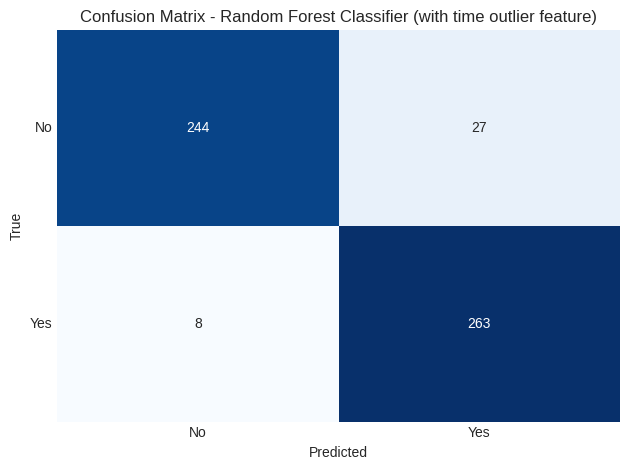

In [75]:
cm = confusion_matrix(y_test_c, y_pred_rf_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest Classifier (with time outlier feature)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0.5, 1.5], ['No', 'Yes'])
plt.yticks([0.5, 1.5], ['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

# Система предсказания времени дожития

Time Prediction Model Performance (RandomForestRegressor):
  R²   = 0.7286
  RMSE = 291.3372
  MAE  = 220.6589


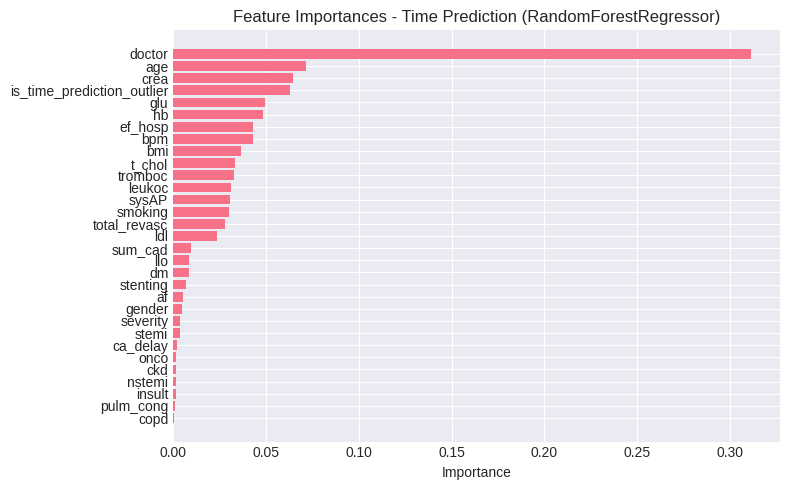

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Prepare data for time prediction (regression)
# Features for regression should be all columns used for classification, minus 'target', plus 'time' is the target
X_reg = df_upsampled.drop(['time', 'target'], axis=1)
y_reg = df_upsampled['time']

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale numerical features (assuming X_reg contains numerical features that need scaling)
scaler_reg = StandardScaler()
# Identify numerical columns in X_reg for scaling
numerical_cols_reg = X_reg.select_dtypes(include=np.number).columns

X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[numerical_cols_reg] = scaler_reg.fit_transform(X_train_reg[numerical_cols_reg])
X_test_reg_scaled[numerical_cols_reg] = scaler_reg.transform(X_test_reg[numerical_cols_reg])

# Train RandomForestRegressor model
rf_reg_prediction = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg_prediction.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_time_model = rf_reg_prediction.predict(X_test_reg_scaled)

# Evaluate the model
r2_time_model = r2_score(y_test_reg, y_pred_time_model)
rmse_time_model = np.sqrt(mean_squared_error(y_test_reg, y_pred_time_model))
mae_time_model = mean_absolute_error(y_test_reg, y_pred_time_model)

print("Time Prediction Model Performance (RandomForestRegressor):")
print(f"  R²   = {r2_time_model:.4f}")
print(f"  RMSE = {rmse_time_model:.4f}")
print(f"  MAE  = {mae_time_model:.4f}")

# Display feature importances
feat_imp_reg = pd.DataFrame({
    'feature': X_reg.columns,
    'importance': rf_reg_prediction.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_reg['feature'], feat_imp_reg['importance'])
plt.title('Feature Importances - Time Prediction (RandomForestRegressor)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

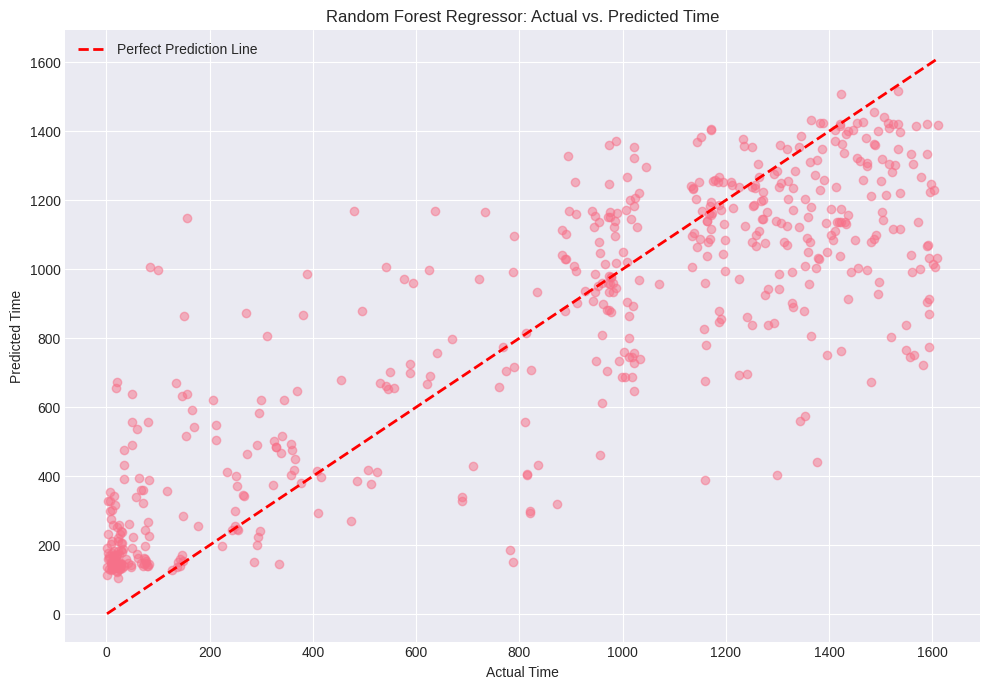

In [77]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test_reg, y_pred_time_model, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Time')
plt.ylabel('Predicted Time')
plt.title('Random Forest Regressor: Actual vs. Predicted Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Comparison of Actual vs. Predicted Time:


,Actual_Time,Predicted_Time,Residual
1044,1313,1079.156568,233.843432
439,1591,1070.210107,520.789893
1729,344,621.649478,-277.649478
296,1425,1362.970952,62.029048
2211,1005,687.190358,317.809642
479,1377,441.418834,935.581166
1084,50,489.138858,-439.138858
2080,60,536.505429,-476.505429
2204,292,491.393279,-199.393279
318,1569,1416.076748,152.923252


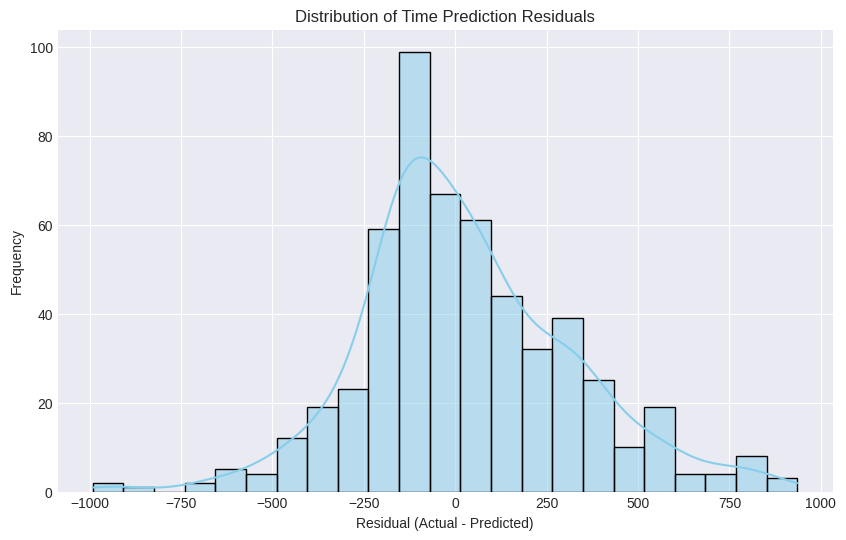


Descriptive statistics for Residuals:


,Residual
count,542.000000
mean,29.056083
std,290.152401
min,-991.135725
25%,-143.325553
50%,-1.833113
75%,200.316774
max,935.581166


In [78]:
time_comparison_df = pd.DataFrame({
    'Actual_Time': y_test_reg,
    'Predicted_Time': y_pred_time_model,
    'Residual': y_test_reg - y_pred_time_model
})

print("Comparison of Actual vs. Predicted Time:")
display(time_comparison_df.head(10))

# Further analysis of residuals
plt.figure(figsize=(10, 6))
sns.histplot(time_comparison_df['Residual'], kde=True, color='skyblue')
plt.title('Distribution of Time Prediction Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("\nDescriptive statistics for Residuals:")
display(time_comparison_df['Residual'].describe())